# Part 1c: Training a Complete Neural Network Potential

## Where We Are

| Part | What We Built |
|:---|:---|
| **1a** | A neuron — the building block |
| **1b** | Forces via autograd — the physics constraint |
| **1c** | **Training a complete NNP** — putting it all together |

## What We'll Do

1. Generate a realistic 1D potential energy surface (Morse potential)
2. Define a small neural network
3. Train it with **both energy AND force loss**
4. Watch it learn the PES
5. Evaluate its accuracy
6. Understand **why** this works and where it fails

## The Big Question

> *"Can a neural network learn a potential energy surface from scratch, using only (r, E, F) data?"*

**Yes. And by the end of this notebook, you'll have done it.**

## The Morse Potential: A Realistic PES

We need a "ground truth" potential to learn. The **Morse potential** is a classic model for diatomic molecules:

$$E(r) = D_e \left[ 1 - e^{-a(r - r_e)} \right]^2 - D_e$$

where:
- $D_e$ = dissociation energy (well depth)
- $r_e$ = equilibrium bond length
- $a$ = width parameter (controls stiffness)

**Why Morse?**
- It has a **repulsive wall** at short $r$
- It has an **attractive well** at $r_e$
- It **dissociates** to a finite energy at large $r$
- It's more realistic than a harmonic spring

This is exactly the kind of PES we want our MLFF to learn.

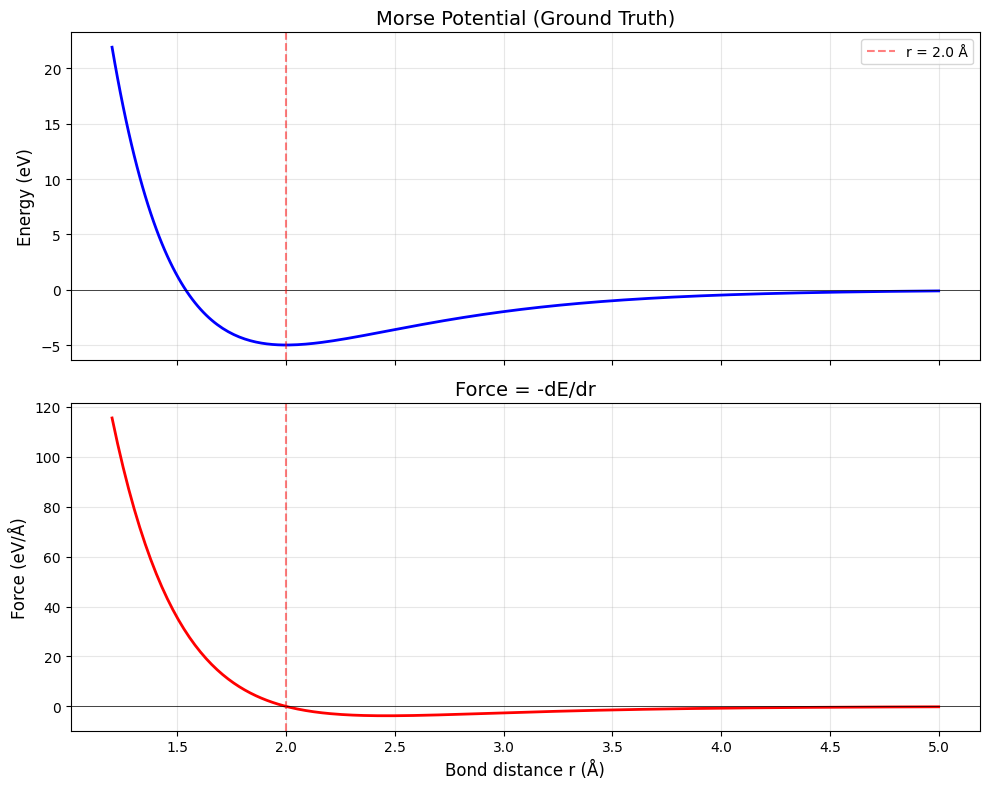

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# DEFINE THE MORSE POTENTIAL
# ============================================================
def true_energy(r, De=5.0, a=1.5, re=2.0):
    """Morse potential: realistic diatomic PES."""
    return De * (1 - np.exp(-a * (r - re)))**2 - De

def true_force(r, De=5.0, a=1.5, re=2.0):
    """Analytical force: F = -dE/dr."""
    exp_term = np.exp(-a * (r - re))
    return -2 * De * a * exp_term * (1 - exp_term)

# ============================================================
# VISUALIZE THE MORSE POTENTIAL
# ============================================================
r_plot = np.linspace(1.2, 5.0, 300)
E_plot = true_energy(r_plot)
F_plot = true_force(r_plot)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(r_plot, E_plot, 'b-', linewidth=2)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].axvline(x=2.0, color='red', linestyle='--', alpha=0.5, label='r = 2.0 Å')
axes[0].set_ylabel('Energy (eV)', fontsize=12)
axes[0].set_title('Morse Potential (Ground Truth)', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(r_plot, F_plot, 'r-', linewidth=2)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].axvline(x=2.0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Bond distance r (Å)', fontsize=12)
axes[1].set_ylabel('Force (eV/Å)', fontsize=12)
axes[1].set_title('Force = -dE/dr', fontsize=14)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('morse_potential.png', dpi=150)
plt.show()

## Generating Training Data

In a real MLFF workflow, you'd run DFT to get energies and forces.

Here, we use the **analytical Morse potential** as our "DFT."

We'll sample 100 points across the PES, with denser sampling near the equilibrium.

In [10]:
# ============================================================
# GENERATE TRAINING DATA
# ============================================================
r_data = np.linspace(1.2, 5.0, 100)
E_data = true_energy(r_data)
F_data = true_force(r_data)

# ============================================================
# NORMALIZE THE DATA
# ============================================================
r_mean, r_std = r_data.mean(), r_data.std()
E_mean, E_std = E_data.mean(), E_data.std()
F_scale = E_std / r_std          # converts normalized force to physical force

r_norm = (r_data - r_mean) / r_std
E_norm = (E_data - E_mean) / E_std
F_norm = F_data / F_scale

print(f"Data statistics:")
print(f"  r range: [{r_data.min():.2f}, {r_data.max():.2f}] Å")
print(f"  E range: [{E_data.min():.2f}, {E_data.max():.2f}] eV")
print(f"  F range: [{F_data.min():.2f}, {F_data.max():.2f}] eV/Å")

# ============================================================
# CONVERT TO TENSORS
# ============================================================
import torch

r_tensor = torch.tensor(r_norm, dtype=torch.float32).view(-1, 1)
E_tensor = torch.tensor(E_norm, dtype=torch.float32).view(-1, 1)
F_tensor = torch.tensor(F_norm, dtype=torch.float32).view(-1, 1)

print(f"\nTensor shapes:")
print(f"  r_tensor: {r_tensor.shape}")
print(f"  E_tensor: {E_tensor.shape}")
print(f"  F_tensor: {F_tensor.shape}")

Data statistics:
  r range: [1.20, 5.00] Å
  E range: [-5.00, 21.91] eV
  F range: [-3.75, 115.55] eV/Å

Tensor shapes:
  r_tensor: torch.Size([100, 1])
  E_tensor: torch.Size([100, 1])
  F_tensor: torch.Size([100, 1])


## Splitting the Data

We need to know if our model is actually learning physics or just memorizing.

**The three-way split:**
- **Training (70%):** The model learns from this
- **Validation (15%):** Used to tune hyperparameters
- **Test (15%):** Never seen during training; final evaluation

We'll use a **random split** here. In real MD workflows, you'd use **block splitting** (by trajectory time) to avoid leakage.

In [11]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================
n_total = len(r_tensor)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

indices = np.random.permutation(n_total) # shuffle indices
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

r_train = r_tensor[train_idx].clone().requires_grad_(True)
E_train = E_tensor[train_idx]
F_train = F_tensor[train_idx]

r_val = r_tensor[val_idx].clone().requires_grad_(True)
E_val = E_tensor[val_idx]
F_val = F_tensor[val_idx]

r_test = r_tensor[test_idx].clone().requires_grad_(True)
E_test = E_tensor[test_idx]
F_test = F_tensor[test_idx]

print(f"Data split: Train={len(r_train)}, Val={len(r_val)}, Test={len(r_test)}")

Data split: Train=70, Val=15, Test=15


## The Neural Network Architecture

We'll use a simple feedforward network:

- **Input:** 1 feature (normalized bond distance)
- **Hidden layers:** 2 layers × 32 neurons each
- **Activation:** SiLU (smooth, differentiable)
- **Output:** 1 scalar (normalized energy)

**Why this architecture?**
- Small enough to train in seconds
- Large enough to fit the Morse potential
- Same design principles as MACE/SchNet, just smaller

In [12]:
import torch.nn as nn

# ============================================================
# DEFINE THE MODEL
# ============================================================
class TinyNN(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, r):
        return self.net(r)

model = TinyNN(hidden=32)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Total parameters: {n_params}")

TinyNN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): SiLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): SiLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters: 1153


## Training with Energy + Force Loss

The loss function is the heart of the training:

$$\mathcal{L} = \lambda_E \cdot \text{MSE}(E_{\text{pred}}, E_{\text{true}}) + \lambda_F \cdot \text{MSE}(F_{\text{pred}}, F_{\text{true}})$$

where $F_{\text{pred}} = -\nabla E_{\text{pred}}$.

**Key hyperparameters:**
- `lambda_force`: How much we care about forces vs. energy
- `lr`: Learning rate (how big are the weight updates)
- `n_epochs`: How many times we loop over the data

Let's train.

In [13]:
# # =========================================
# TRAINING
# =========================================
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 5000
lambda_force = 10.0

train_losses_E = []
train_losses_F = []
val_losses_E = []
val_losses_F = []

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()

    E_pred = model(r_train)
    loss_E = loss_fn(E_pred, E_train)

    F_pred = -torch.autograd.grad(
        E_pred.sum(), r_train,
        create_graph=True, retain_graph=True
    )[0]
    loss_F = loss_fn(F_pred, F_train)

    loss = loss_E + lambda_force * loss_F
    loss.backward()
    optimizer.step()

    train_losses_E.append(loss_E.item())
    train_losses_F.append(loss_F.item())

    if epoch % 100 == 0:
        model.eval()
        E_val_pred = model(r_val)
        val_loss_E = loss_fn(E_val_pred, E_val).item()

        F_val_pred = -torch.autograd.grad(
            E_val_pred.sum(), r_val,
            create_graph=False, retain_graph=False
        )[0]
        val_loss_F = loss_fn(F_val_pred, F_val).item()

        val_losses_E.append(val_loss_E)
        val_losses_F.append(val_loss_F)

        if epoch % 500 == 0:
            print(f"{epoch:>6} | {loss_E.item():>10.5f} | "
                  f"{loss_F.item():>10.5f} | {val_loss_E:>10.5f} | "
                  f"{val_loss_F:>10.5f}")

print("\nTraining complete!")


     0 |    0.55499 |   19.10858 |    1.43966 |   48.84212
   500 |    0.00182 |    0.08998 |    0.00373 |    1.80645
  1000 |    0.00053 |    0.02198 |    0.00083 |    0.71181
  1500 |    0.00009 |    0.00576 |    0.00036 |    0.34174
  2000 |    0.00002 |    0.00217 |    0.00022 |    0.19768
  2500 |    0.00001 |    0.00103 |    0.00015 |    0.13289
  3000 |    0.00001 |    0.00055 |    0.00010 |    0.09637
  3500 |    0.00000 |    0.00037 |    0.00008 |    0.07498
  4000 |    0.00000 |    0.00029 |    0.00006 |    0.06269
  4500 |    0.00000 |    0.00024 |    0.00005 |    0.05489

Training complete!


## Did It Learn Physics?

Let's plot the trained model against the true Morse potential.

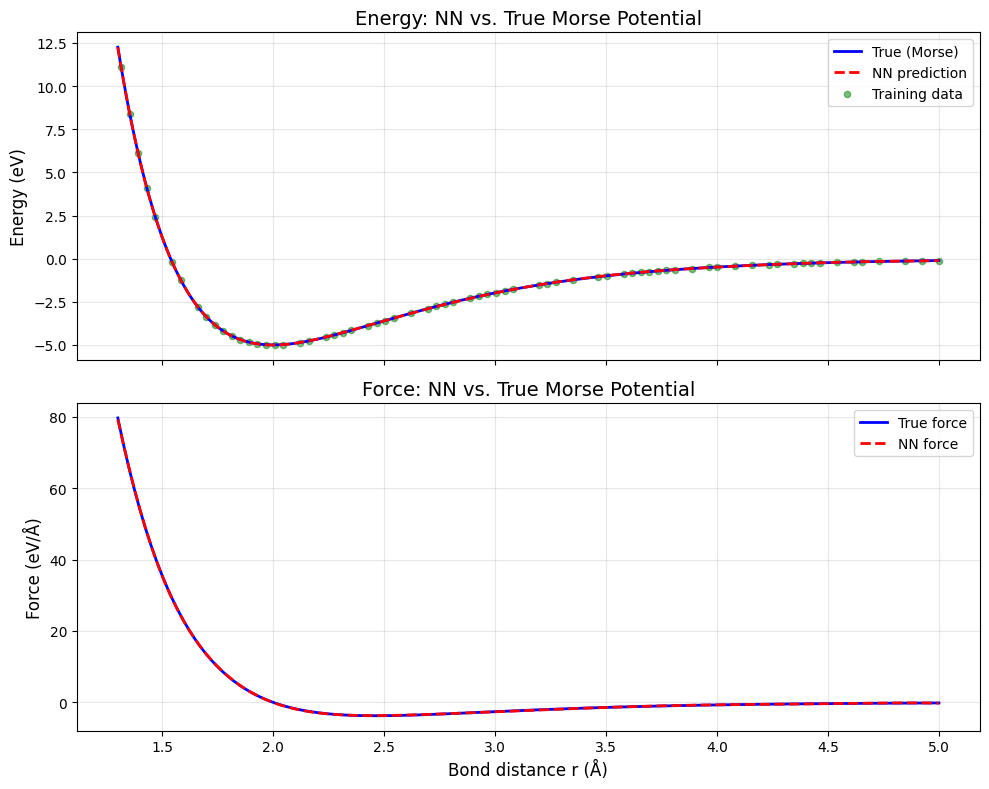

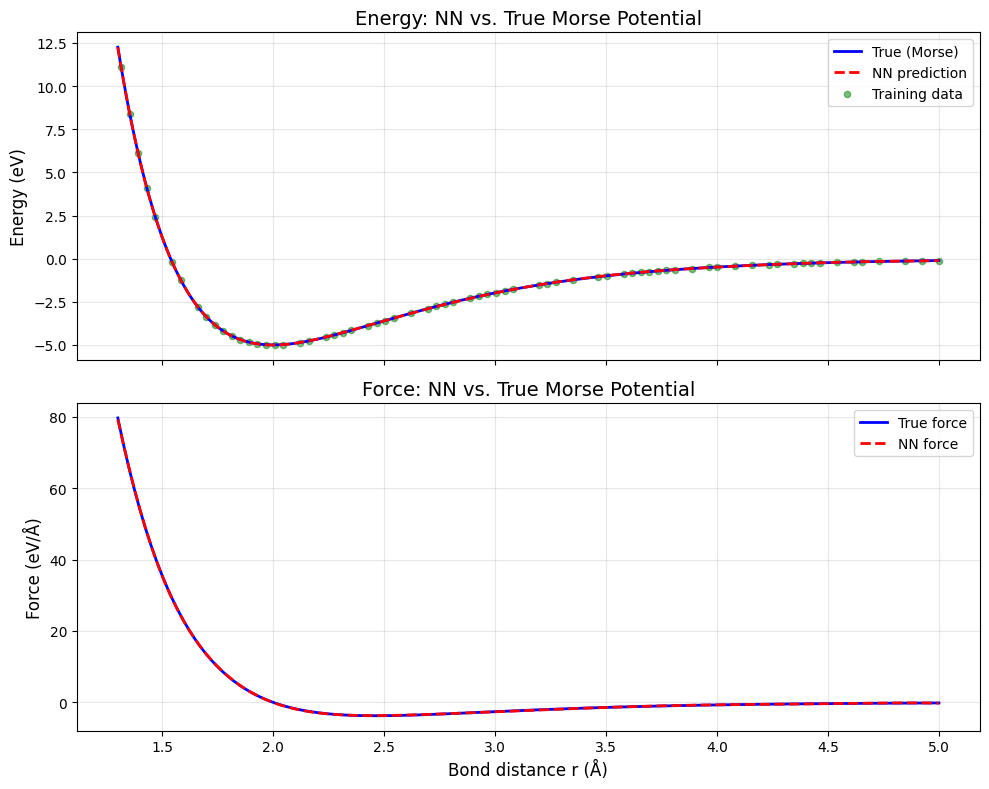

In [14]:
# =========================================
# EVALUATE ON DENSE GRID
# =========================================
model.eval()

r_grid = np.linspace(1.3, 5.0, 300)
r_grid_norm = (r_grid - r_mean) / r_std
r_grid_tensor = torch.tensor(r_grid_norm, dtype=torch.float32).unsqueeze(1)
r_grid_tensor.requires_grad_(True)

E_pred_norm = model(r_grid_tensor)
E_pred = E_pred_norm.detach().numpy().ravel() * E_std + E_mean

F_pred_norm = -torch.autograd.grad(E_pred_norm.sum(), r_grid_tensor)[0]
F_pred = F_pred_norm.detach().numpy().ravel() * F_scale

E_true = true_energy(r_grid)
F_true = true_force(r_grid)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(r_grid, E_true, 'b-', linewidth=2, label='True (Morse)')
axes[0].plot(r_grid, E_pred, 'r--', linewidth=2, label='NN prediction')
axes[0].scatter(r_data[train_idx], E_data[train_idx],
                c='green', s=20, alpha=0.5, label='Training data')
axes[0].set_ylabel('Energy (eV)', fontsize=12)
axes[0].set_title('Energy: NN vs. True Morse Potential', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(r_grid, F_true, 'b-', linewidth=2, label='True force')
axes[1].plot(r_grid, F_pred, 'r--', linewidth=2, label='NN force')
axes[1].set_xlabel('Bond distance r (Å)', fontsize=12)
axes[1].set_ylabel('Force (eV/Å)', fontsize=12)
axes[1].set_title('Force: NN vs. True Morse Potential', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('morse_fit.png', dpi=150)
plt.show()

# =========================================
# EVALUATE ON DENSE GRID
# =========================================
model.eval()

r_grid = np.linspace(1.3, 5.0, 300)
r_grid_norm = (r_grid - r_mean) / r_std
r_grid_tensor = torch.tensor(r_grid_norm, dtype=torch.float32).unsqueeze(1)
r_grid_tensor.requires_grad_(True)

E_pred_norm = model(r_grid_tensor)
E_pred = E_pred_norm.detach().numpy().ravel() * E_std + E_mean

F_pred_norm = -torch.autograd.grad(E_pred_norm.sum(), r_grid_tensor)[0]
F_pred = F_pred_norm.detach().numpy().ravel() * F_scale

E_true = true_energy(r_grid)
F_true = true_force(r_grid)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(r_grid, E_true, 'b-', linewidth=2, label='True (Morse)')
axes[0].plot(r_grid, E_pred, 'r--', linewidth=2, label='NN prediction')
axes[0].scatter(r_data[train_idx], E_data[train_idx],
                c='green', s=20, alpha=0.5, label='Training data')
axes[0].set_ylabel('Energy (eV)', fontsize=12)
axes[0].set_title('Energy: NN vs. True Morse Potential', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(r_grid, F_true, 'b-', linewidth=2, label='True force')
axes[1].plot(r_grid, F_pred, 'r--', linewidth=2, label='NN force')
axes[1].set_xlabel('Bond distance r (Å)', fontsize=12)
axes[1].set_ylabel('Force (eV/Å)', fontsize=12)
axes[1].set_title('Force: NN vs. True Morse Potential', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('morse_fit.png', dpi=150)
plt.show()

## Diagnosing Training Health

The training curves tell you if your model is healthy or sick.

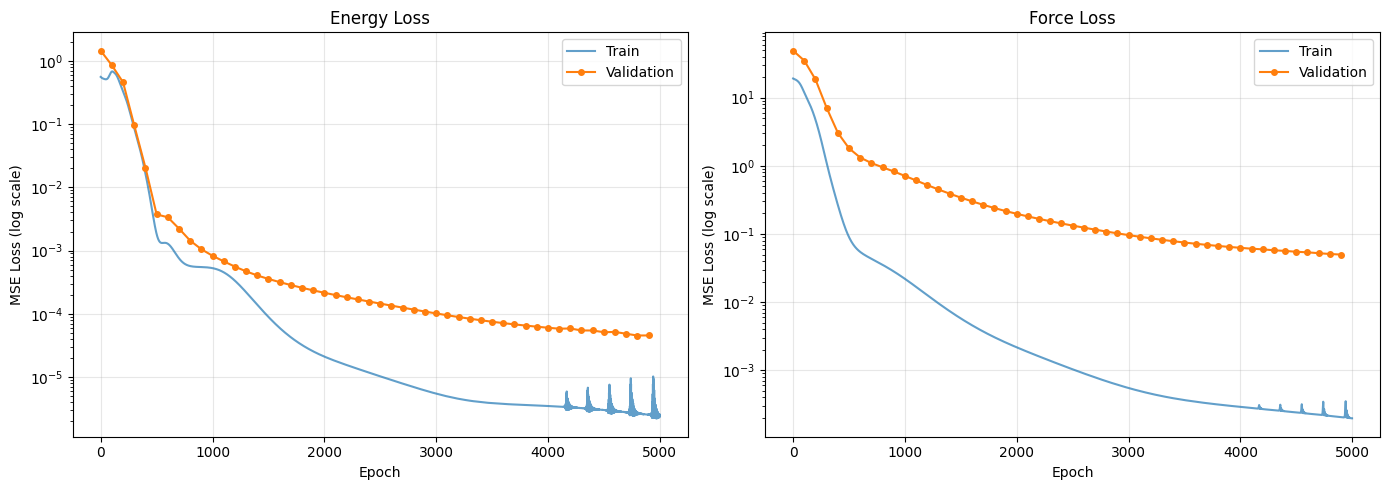

In [15]:
# =========================================
# TRAINING CURVES
# =========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(train_losses_E, label='Train', alpha=0.7)
axes[0].semilogy(np.arange(0, n_epochs, 100), val_losses_E,
                 'o-', label='Validation', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss (log scale)')
axes[0].set_title('Energy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(train_losses_F, label='Train', alpha=0.7)
axes[1].semilogy(np.arange(0, n_epochs, 100), val_losses_F,
                 'o-', label='Validation', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss (log scale)')
axes[1].set_title('Force Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## What Does Overfitting Look Like?

Let's deliberately overfit by using a tiny training set and a big model.

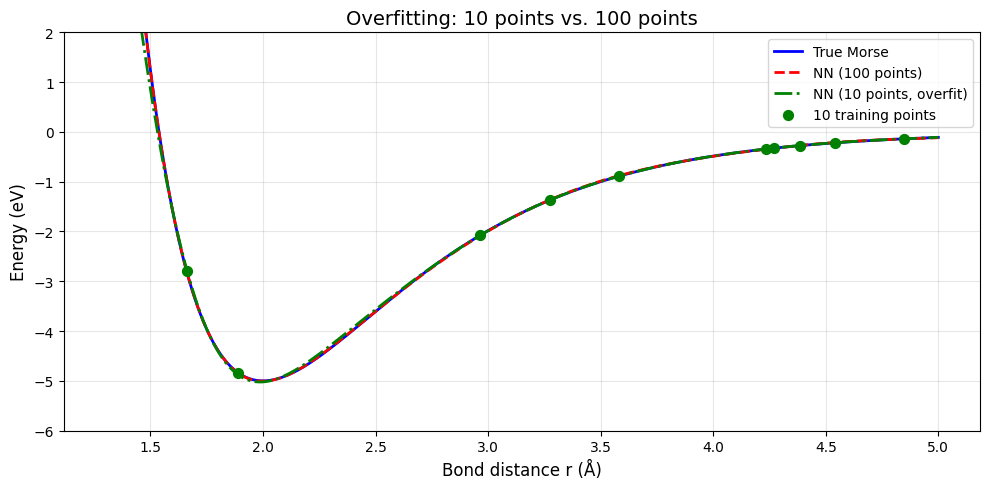

In [18]:
# ============================================================
# OVERFITTING DEMO
# ============================================================
n_small = 10
small_idx = np.random.choice(train_idx, n_small, replace=False)

r_small = r_tensor[small_idx].clone().requires_grad_(True)
E_small = E_tensor[small_idx]
F_small = F_tensor[small_idx]

big_model = TinyNN(hidden=256)
optimizer_big = torch.optim.Adam(big_model.parameters(), lr=1e-3)

small_train_losses = []
small_val_losses = []

for epoch in range(5000):
    big_model.train()
    optimizer_big.zero_grad()

    E_pred = big_model(r_small)
    loss_E = loss_fn(E_pred, E_small)

    F_pred = -torch.autograd.grad(
        E_pred.sum(), r_small,
        create_graph=True, retain_graph=True
    )[0]
    loss_F = loss_fn(F_pred, F_small)

    loss = loss_E + 10.0 * loss_F
    loss.backward()
    optimizer_big.step()

    small_train_losses.append(loss.item())

    if epoch % 100 == 0:
        big_model.eval()
        E_val_pred = big_model(r_val)
        small_val_losses.append(loss_fn(E_val_pred, E_val).item())

# ============================================================
# COMPARE: SMALL DATA vs FULL DATA
# ============================================================
model.eval()
big_model.eval()

# Recompute both predictions as pure NumPy arrays (no grad)
with torch.no_grad():
    r_grid_plain = torch.tensor(r_grid_norm, dtype=torch.float32).unsqueeze(1)

    E_pred = (model(r_grid_plain).numpy().ravel() * E_std + E_mean)
    E_big_pred = (big_model(r_grid_plain).numpy().ravel() * E_std + E_mean)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(r_grid, E_true, 'b-', linewidth=2, label='True Morse')
ax.plot(r_grid, E_pred, 'r--', linewidth=2, label='NN (100 points)')
ax.plot(r_grid, E_big_pred, 'g-.', linewidth=2, label='NN (10 points, overfit)')
ax.scatter(r_data[small_idx], E_data[small_idx],
           c='green', s=50, zorder=5, label='10 training points')
ax.set_xlabel('Bond distance r (Å)', fontsize=12)
ax.set_ylabel('Energy (eV)', fontsize=12)
ax.set_title('Overfitting: 10 points vs. 100 points', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-6, 2)
plt.tight_layout()
plt.savefig('overfitting_demo.png', dpi=150)
plt.show()

## How This Scales to Real Systems

Our demo used:
- 1 distance (r)
- 1 output (E)
- 2 hidden layers × 32 neurons

A real MLFF uses:
- **Thousands of descriptors** (SOAP, ACE, atom-centered symmetry functions)
- **Sum over atomic contributions** (energy is a sum of local energies)
- **Millions of parameters** (MACE, NequIP, Allegro)
- **Periodic boundary conditions** (infinite crystals)

**But the training workflow is IDENTICAL:**

| Step | Our Demo | Real MLFF |
|:---|:---|:---|
| 1. Get data | Morse potential | DFT calculations |
| 2. Normalize | r, E, F | Per-element statistics |
| 3. Define model | TinyNN | MACE / NequIP |
| 4. Loss function | MSE(E) + λ·MSE(F) | Same, but weighted |
| 5. Autograd forces | F = -dE/dr | F = -∇E |
| 6. Train | Adam optimizer | AdamW with scheduling |
| 7. Validate | Held-out test set | Held-out trajectories |

**The physics and math are the same. The scale is different.**

## Summary

| Concept | Key Takeaway |
|:---|:---|
| **Morse potential** | Realistic PES with repulsion, well, and dissociation |
| **Data generation** | Sample r, compute E and F analytically |
| **Normalization** | Essential for stable training |
| **Train/val/test split** | Prevents overfitting and data leakage |
| **TinyNN** | 2 hidden layers, 32 neurons, SiLU activation |
| **Loss function** | L = MSE(E) + λ·MSE(F) |
| **Autograd forces** | F = -∇E, computed exactly |
| **Overfitting** | Big model + little data = wiggles |

## The Complete Workflow

1. Generate data (r, E, F)
2. Normalize
3. Split into train/val/test
4. Define model
5. Train with energy + force loss
6. Evaluate on test set
7. Diagnose overfitting with training curves
8. If overfitting: more data or smaller model
9. If underfitting: bigger model or longer training